In [1]:
from pathlib import Path
from collections import Counter
import html
import json
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from IPython.display import display

# Настройки

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

In [3]:
PROJECT_DIR = next((p for p in [Path.cwd(), Path.cwd() / "work", Path("/home/jovyan/work")]
                    if (p / "data/train.csv").exists() and (p / "data/test.csv").exists()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError("Укажите PROJECT_DIR — папку проекта с data/train.csv и data/test.csv")
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "eda_results"
AUDIT_DIR = PROJECT_DIR / "audit_results"
for directory in [OUT_DIR, AUDIT_DIR]:
    directory.mkdir(exist_ok=True)

In [4]:
SEED = 42
VAL_SIZE = 0.10
BATCH_SIZE = 64
PAD_IDX, UNK_IDX = 0, 1
MIN_FREQ = 2
LENGTH_CANDIDATES = [32, 64, 96, 128, 256]
VOCAB_CANDIDATES = [10_000, 20_000, 30_000, 50_000]
MAX_TRUNCATED_PERCENT = 0.1
MIN_COVERAGE_PERCENT = 98.0
CLASS_NAMES = {1: "Мир", 2: "Спорт", 3: "Бизнес", 4: "Наука и технологии"}

In [5]:
EMBEDDING_DIM = 64
HIDDEN_DIM = 64
DROPOUT = 0.3
LEARNING_RATE = 0.001
MAX_EPOCHS = 10
PATIENCE = 2
CLIP_NORM = 1.0
DEVICE = torch.device("cpu")
CPU_THREADS = 2
RETRAIN_MODELS = set()  # Например: {"GRU"}. По умолчанию используются сохранённые веса.

In [6]:
MODEL_SPECS = {
    "SimpleRNN": ("RNN", False, "simple_rnn_results", "best_simple_rnn.pt"),
    "LSTM": ("LSTM", False, "lstm_results", "best_lstm.pt"),
    "GRU": ("GRU", False, "gru_results", "best_gru.pt"),
    "Bidirectional LSTM": ("LSTM", True, "bilstm_results", "best_bilstm.pt"),
}

In [7]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(CPU_THREADS)

Все четыре модели уже обучены. При обычном запуске ноутбук пересоздаёт подготовку данных, загружает лучшие веса и проверяет тестовые метрики. Обучение повторно не запускается. Его реализация сохранена в общей функции; для нового эксперимента имя модели можно добавить в `RETRAIN_MODELS`. Новые веса сохраняются отдельно в `audit_results/retrained`.

Выводы ниже относятся к сохранённым экспериментам с seed=42. При новом обучении нужно обновить текстовые выводы по полученным результатам.

# 1. Разведочный анализ

In [8]:
frames = {split: pd.read_csv(DATA_DIR / f"{split}.csv") for split in ["train", "test"]}

In [9]:
for split, df in frames.items():
    print(f"{split}: {len(df):,} документов; столбцы: {list(df.columns)}")
frames["train"].head(3)

train: 120,000 документов; столбцы: ['Class Index', 'Title', 'Description']
test: 7,600 документов; столбцы: ['Class Index', 'Title', 'Description']


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed an..."
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are e...


Загружены две выборки: 120 000 обучающих и 7 600 тестовых документов. Каждая запись содержит индекс класса, заголовок и описание новости. Разделение на train и test уже задано в исходных файлах.

Class Index - индекс классов, где 1 - мир, 2 - спорт, 3 - бизнес, 4 - научные и технические новости

Title - заголовок статьи

Description - описание статьи

## Качество данных и объединение полей

Пропуски заменяем пустой строкой только при создании `text`. Между заголовком и описанием вставляем пробел, убираем пробелы по краям. Сохраняем регистр, пунктуацию и исходные поля. Длина в символах включает пробелы; длина в словах — число фрагментов, разделённых пробельными символами (`str.split`), а не число токенов будущей модели.

In [10]:
for df in frames.values():
    df["text"] = (df["Title"].fillna("").astype(str).str.strip() + " " +
                  df["Description"].fillna("").astype(str).str.strip()).str.strip()

In [11]:
for df in frames.values():
    for column in ["Title", "Description"]:
        df[f"{column}_words"] = df[column].fillna("").str.split().str.len()
    df["n_words"] = df["text"].str.split().str.len()
    df["n_chars"] = df["text"].str.len()

In [12]:
quality = []
for split, df in frames.items():
    row = {"split": split, "documents": len(df),
           "missing_class": int(df["Class Index"].isna().sum()),
           "duplicate_rows": int(df.duplicated(["Class Index", "Title", "Description"]).sum())}
    for column in ["Title", "Description"]:
        row[f"missing_{column}"] = int(df[column].isna().sum())
        row[f"blank_{column}"] = int(df[column].fillna("").str.strip().eq("").sum())
    row["empty_text"] = int(df["text"].eq("").sum())
    row["duplicate_texts"] = int(df["text"].duplicated().sum())
    quality.append(row)

In [13]:
quality = pd.DataFrame(quality).set_index("split")
quality

,documents,missing_class,duplicate_rows,missing_Title,blank_Title,missing_Description,blank_Description,empty_text,duplicate_texts
split,,,,,,,,,
train,120000,0,0,0,0,0,0,0,43
test,7600,0,0,0,0,0,0,0,0


Пропусков в метках классов, заголовках и описаниях нет; пустых объединённых текстов также не обнаружено. Полностью одинаковых строк нет, но в train найдено 43 повторных вхождения объединённого текста сверх первого. В test повторов текста нет. Следовательно, полнота данных хорошая, однако повторяющиеся тексты требуют отдельной проверки.

In [14]:
frames["train"][["Title", "Description", "text"]].head(3)

,Title,Description,text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.","Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindli..."
1,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed an...",Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Gr...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are e...,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\abou...


Поле `text` содержит заголовок и описание, соединённые пробелом. В показанных примерах информация из обоих полей сохранена, исходные столбцы доступны для проверки. Вместе с содержанием сохранились обозначения источников и обратные слеши: объединение полей не выполняет очистку текста.

In [15]:
train_df, test_df = frames["train"], frames["test"]
overlap = set(train_df["text"]) & set(test_df["text"])
conflicts = pd.concat([train_df, test_df]).groupby("text")["Class Index"].nunique().gt(1).sum()

In [16]:
print(f"Совпадающих уникальных text между train и test: {len(overlap)}")
print(f"Уникальных text с разными метками класса: {conflicts}")
print("Дубликаты считаются сверх первого вхождения; строки автоматически не удалены.")

Совпадающих уникальных text между train и test: 2
Уникальных text с разными метками класса: 14
Дубликаты считаются сверх первого вхождения; строки автоматически не удалены.


Между train и test обнаружены 2 одинаковых уникальных текста. Такие пересечения могут завышать оценку качества будущей модели. Кроме того, в совокупности двух выборок найдены 14 уникальных текстов с разными метками класса — это неоднозначность разметки, которую стоит проверить перед обучением. На данном этапе записи не удалялись.

## Распределение документов по классам

In [17]:
class_tables = []
for split, df in frames.items():
    counts = df["Class Index"].value_counts(dropna=False).sort_index()
    class_tables.append(pd.DataFrame({"split": split, "class": counts.index,
                                     "count": counts.values, "percent": counts.values / len(df) * 100}))

In [18]:
class_distribution = pd.concat(class_tables, ignore_index=True)
class_distribution

,split,class,count,percent
0,train,1,30000,25.0
1,train,2,30000,25.0
2,train,3,30000,25.0
3,train,4,30000,25.0
4,test,1,1900,25.0
5,test,2,1900,25.0
6,test,3,1900,25.0
7,test,4,1900,25.0


Все четыре класса представлены поровну: в train по 30 000 документов, в test по 1 900 документов. Доля каждого класса составляет 25% в обеих выборках. Дисбаланса классов нет, поэтому компенсация дисбаланса по частотам здесь не требуется.

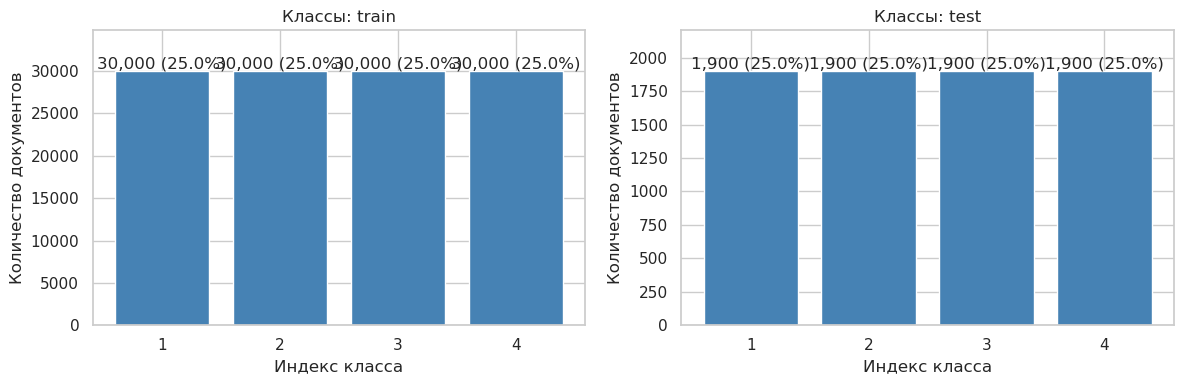

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, frames):
    part = class_distribution.query("split == @split")
    ax.bar(part["class"].astype(str), part["count"], color="steelblue")
    ax.set(title=f"Классы: {split}", xlabel="Индекс класса", ylabel="Количество документов")
    for i, (_, row) in enumerate(part.iterrows()):
        ax.text(i, row["count"], f'{int(row["count"]):,} ({row["percent"]:.1f}%)', ha="center", va="bottom")
    ax.set_ylim(0, part["count"].max() * 1.16)
fig.tight_layout()
fig.savefig(OUT_DIR / "classes.png", dpi=160)
plt.show()

## Длины заголовков, описаний и объединённых текстов

In [20]:
length_stats = pd.concat({split: df[["Title_words", "Description_words", "n_words", "n_chars"]]
    .describe(percentiles=[.25, .5, .75, .9, .95, .99]).T for split, df in frames.items()},
    names=["split", "metric"])
length_stats.round(2)

count    mean    std    min    25%    50%    75%  \
split metric                                                                   
train Title_words        120000.0    6.78   2.09    1.0    5.0    7.0    8.0   
      Description_words  120000.0   31.06   9.76    1.0   25.0   30.0   36.0   
      n_words            120000.0   37.84  10.09    4.0   32.0   37.0   43.0   
      n_chars            120000.0  236.26  66.46   17.0  196.0  232.0  266.0   
test  Title_words          7600.0    6.76   2.11    1.0    5.0    7.0    8.0   
      Description_words    7600.0   30.96   9.80    4.0   25.0   30.0   36.0   
      n_words              7600.0   37.72  10.13   11.0   32.0   37.0   43.0   
      n_chars              7600.0  235.10  65.23  100.0  196.0  231.0  265.0   

                           90%     95%     99%     max  
split metric                                            
train Title_words          9.0   10.00   12.00    19.0  
      Description_words   41.0   45.00   63.00   173.0  
      n_words             48.0   53.00   70.00   177.0  
      n_chars            300.0  342.00  463.01  1012.0  
test  Title_words         10.0   11.00   12.00    17.0  
      Description_words   41.0   45.00   62.00   129.0  
      n_words             48.0   52.00   69.00   137.0  
      n_chars            298.0  335.05  444.01   892.0

Заголовки короткие: в train в среднем 6,78 слова, описания — 31,06 слова. После объединения средняя длина составляет 37,84 слова, медиана — 37 слов; половина текстов находится в диапазоне от 32 до 43 слов. Для train 95-й процентиль равен 53 словам, 99-й — 70 словам, максимум — 177 словам. Средняя длина в символах составляет 236,26. В test показатели близки: в среднем 37,72 слова и 235,10 символа. Это указывает на сходство выборок по длинам текстов, но само по себе не доказывает сходство их содержания.

In [21]:
by_class = pd.concat({split: df.groupby("Class Index")[["n_words", "n_chars"]]
                     .agg(["count", "mean", "median", "std", "min", "max"])
                     for split, df in frames.items()}, names=["split", "class"])
by_class.round(2)

n_words                               n_chars                 \
              count   mean median    std min  max   count    mean median   
split class                                                                
train 1       30000  38.88   39.0  10.32   9  145   30000  242.42  243.0   
      2       30000  37.77   37.0   8.88   4  151   30000  224.42  219.0   
      3       30000  37.54   37.0   8.12   8  134   30000  241.13  235.0   
      4       30000  37.19   36.0  12.42   8  177   30000  237.07  230.0   
test  1        1900  38.55   39.0  10.11  15  106    1900  240.20  241.0   
      2        1900  37.57   37.0   8.72  17   90    1900  223.20  219.0   
      3        1900  37.63   37.0   8.06  14  126    1900  239.88  235.0   
      4        1900  37.14   36.0  12.90  11  137    1900  237.10  229.0   

                               
               std  min   max  
split class                    
train 1      63.61   64   865  
      2      50.52   17   853  
      3      64.11  100  1006  
      4      82.20  100  1012  
test  1      62.44  101   611  
      2      49.03  103   486  
      3      60.58  100   814  
      4      82.82  100   892

Средние длины по классам различаются незначительно. В train самые длинные в среднем тексты относятся к мировым новостям (38,88 слова), самые короткие — к научным и техническим новостям (37,19 слова). При этом у научно-технического класса наибольший разброс длин (стандартное отклонение 12,42 слова), а у бизнеса — наименьший (8,12). В test сохраняется аналогичная картина. Спортивные новости короче остальных по средней длине в символах: 224,42 в train и 223,20 в test.

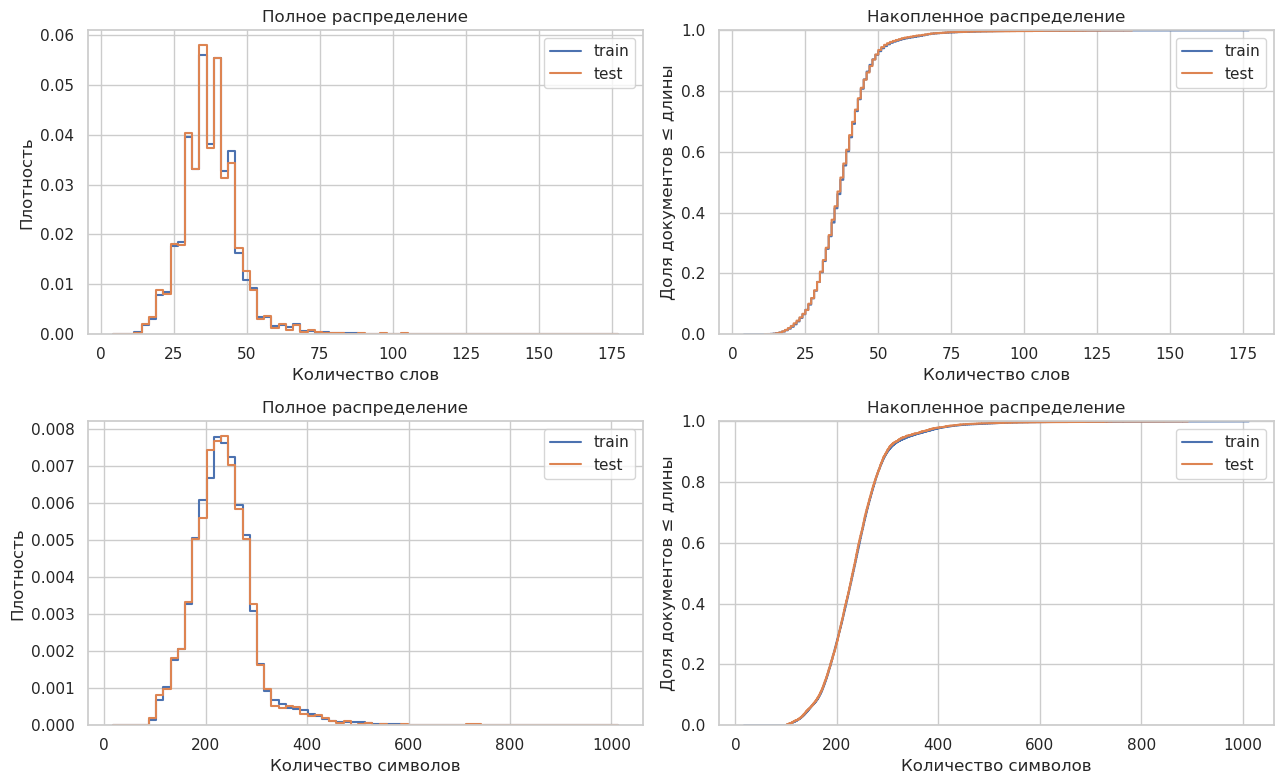

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (metric, label) in enumerate([("n_words", "Количество слов"), ("n_chars", "Количество символов")]):
    bins = np.histogram_bin_edges(np.concatenate([d[metric].to_numpy() for d in frames.values()]), bins=70)
    for split, df in frames.items():
        sns.histplot(df[metric], bins=bins, stat="density", element="step", fill=False,
                     label=split, ax=axes[row, 0])
        sns.ecdfplot(data=df, x=metric, label=split, ax=axes[row, 1])
    axes[row, 0].set(xlabel=label, ylabel="Плотность", title="Полное распределение")
    axes[row, 1].set(xlabel=label, ylabel="Доля документов ≤ длины", title="Накопленное распределение")
    for ax in axes[row]: ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "lengths.png", dpi=160)
plt.show()

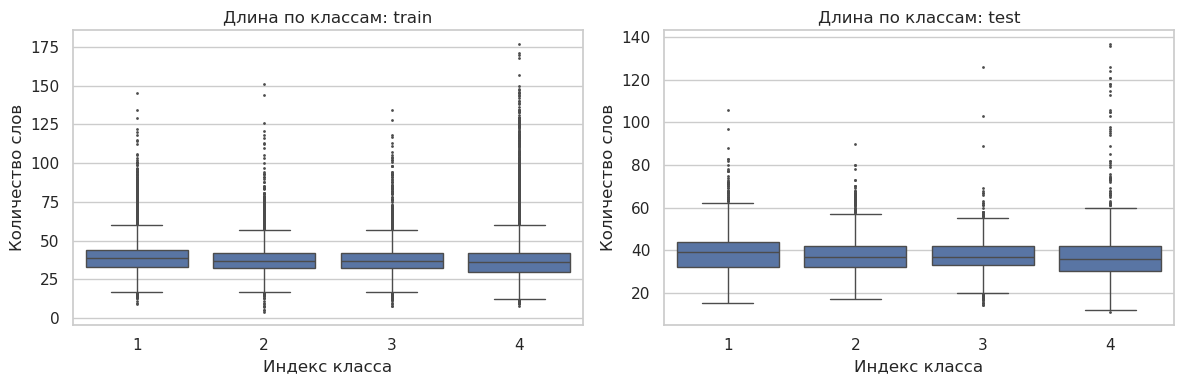

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split, df) in zip(axes, frames.items()):
    sns.boxplot(data=df, x="Class Index", y="n_words", ax=ax, fliersize=1)
    ax.set(title=f"Длина по классам: {split}", xlabel="Индекс класса", ylabel="Количество слов")
fig.tight_layout()
fig.savefig(OUT_DIR / "lengths_by_class.png", dpi=160)
plt.show()

Распределения длин train и test практически совпадают и по словам, и по символам. Основная масса документов сосредоточена около 30–45 слов; редкие длинные тексты образуют правый хвост распределения. Диаграммы размаха показывают близкие медианы классов и длинные тексты во всех категориях. Особенно заметен разброс у научно-технических новостей. Точки за границами «усов» обозначают необычные значения длины, а не автоматически ошибочные документы.

## Короткие и длинные документы

Проверяем крайние значения без автоматического удаления: необычная длина сама по себе не означает ошибку. Длины для будущего ограничения последовательностей следует выбирать по train и уточнять после токенизации.

In [24]:
train_df.nsmallest(3, "n_words")[["Class Index", "text", "n_words", "n_chars"]]

,Class Index,text,n_words,n_chars
22955,2,Top of 3rd #NAME?,4,17
27805,2,Wild re-sign D Schultz #NAME?,5,29
29104,2,Predators re-sign D Zidlicky #NAME?,5,35


Три самых коротких документа относятся к спорту и содержат всего 4–5 слов. Во всех трёх примерах присутствует маркер `#NAME?`, похожий на артефакт обработки данных. Поэтому отсутствие формальных пропусков не гарантирует содержательную полноту описаний: эти записи стоит проверить отдельно, прежде чем выбирать способ очистки.

In [25]:
train_df.nlargest(3, "n_words")[["Class Index", "text", "n_words", "n_chars"]]

,Class Index,text,n_words,n_chars
69024,4,"2004 US Senate Outlook With all the hoopla over Bush and Kerry, some of you may not have been pa...",177,967
19776,4,Making RSS Scale I've been meaning to write about this since I saw a one-page article on the su...,171,998
32433,4,"Kyoto is Dead - Long Live Pragmatism There's troubling news (FT subscription reqd, alternate ...",170,990


Три самых длинных документа относятся к научно-техническому классу и содержат 177, 171 и 170 слов. Их длина существенно превышает 99-й процентиль train (70 слов), поэтому это редкие крайние значения. По показанным сокращённым фрагментам нельзя достоверно оценить корректность разметки или качество текста; сама длина не является достаточным основанием для удаления.

In [26]:
coverage = pd.DataFrame({"limit_words": [32, 64, 128, 256]})
coverage["train_longer_percent"] = [train_df["n_words"].gt(n).mean() * 100 for n in coverage["limit_words"]]
coverage.round(3)

,limit_words,train_longer_percent
0,32,71.909
1,64,1.829
2,128,0.032
3,256,0.000


При ограничении до 32 слов обрезка затронет 71,909% обучающих документов, поэтому такой предел слишком мал для сохранения большинства текстов целиком. Предел 64 слова затронет 1,829%, а 128 слов — около 0,032% документов. При 256 словах обрезки не будет, поскольку максимальная длина равна 177 словам, но потребуется больше дополнения коротких последовательностей. Для дальнейшего эксперимента можно рассмотреть 64 или 128 слов; окончательный предел следует проверить после выбранной токенизации. Проценты здесь показывают долю затронутых документов, а не долю потерянных слов.

# 2. Подготовка данных для обучения

Используем результаты разведочного анализа: очищаем технические артефакты, проверяем повторяющиеся тексты и неоднозначные метки, устраняем пересечения выборок. Исходные CSV не изменяем. Test сохраняем для итоговой оценки, а из очищенной обучающей выборки выделяем 10% для валидации.

Нормализация и токенизация одинаковы для всех выборок. Словарь и параметры ограничения последовательностей выбираем только по **обучающей части после выделения validation**. Метки test не используются для очистки train, построения словаря или подбора параметров.

## Очистка и токенизация

Удаляем `#NAME?`, декодируем HTML-сущности, заменяем обратные слеши и HTML-теги пробелами. Приводим текст к нижнему регистру. Токенизатор выделяет последовательности букв или цифр, сохраняя апостроф внутри слова. Дефисы и прочая пунктуация служат разделителями. Числа, стоп-слова и порядок слов сохраняем; стемминг не применяем.

Документы с испорченным описанием сохраняем, если после очистки остаётся содержательный заголовок. Пустые последовательности исключаем из train; для пустых текстов test предусмотрен `<UNK>`, чтобы не менять размер исходной тестовой выборки.

In [27]:
TOKEN_PATTERN = re.compile(r"[^\W_]+(?:'[^\W_]+)*", flags=re.UNICODE)

In [28]:
def normalize_text(text):
    text = html.unescape(str(text)).replace("#NAME?", " ")
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("\\", " ").replace("’", "'").lower()
    return re.sub(r"\s+", " ", text).strip()

In [29]:
def tokenize_text(text):
    return TOKEN_PATTERN.findall(normalize_text(text))

In [30]:
working = {}
for split, source in frames.items():
    df = source[["Class Index", "Title", "Description", "text"]].copy()
    df["source_row"] = np.arange(len(df))
    df["tokens"] = df["text"].map(tokenize_text)
    df["text_clean"] = df["tokens"].map(" ".join)
    df["token_length"] = df["tokens"].str.len()
    working[split] = df

In [31]:
normalization_rows = [{"split": split, "documents": len(df),
    "rows_with_NAME": int(df.text.str.contains("#NAME?", regex=False).sum()),
    "empty_after_tokenization": int(df.token_length.eq(0).sum())}
    for split, df in working.items()]

In [32]:
normalization_report = pd.DataFrame(normalization_rows)
normalization_report

,split,documents,rows_with_NAME,empty_after_tokenization
0,train,120000,24,0
1,test,7600,2,0


In [33]:
working["train"].loc[working["train"].text.str.contains("#NAME?", regex=False),
    ["source_row", "text", "text_clean", "token_length"]].head(3)

,source_row,text,text_clean,token_length
17812,17812,Sabres agree to terms with 2003 first-round pick Vanek #NAME?,sabres agree to terms with 2003 first round pick vanek,10
21463,21463,"#NAME? September 8, 2004 -- The Yankees are expected to send Major League Baseball a bill for be...",september 8 2004 the yankees are expected to send major league baseball a bill for between 2 and...,50
22955,22955,Top of 3rd #NAME?,top of 3rd,3


Маркер #NAME? удалён из 24 обучающих и 2 тестовых записей. Заголовки и другие содержательные части сохранены. После токенизации пустых документов: train — 0, test — 0. Дальнейшие длины измеряются токенами выбранного токенизатора, поэтому могут отличаться от подсчёта слов в EDA.

## Дубликаты, конфликтующие метки и пересечения

Для сравнения используем нормализованную последовательность токенов: различия только в регистре или пунктуации не должны позволять одному тексту попасть в разные выборки. Все тексты с несколькими метками **в исходном train** исключаем из обучения целиком; правильный класс не угадываем. Среди оставшихся повторов сохраняем первое вхождение.

Совпадения с test удаляем со стороны train, используя только текст test. Исходный test не сокращаем. Для прозрачности сохраняем исключённые записи с причиной и диагностируем повторы внутри test; это проверка целостности набора, а не обучение на test.

In [34]:
pool = working["train"].copy()
removed_parts, cleaning_rows = [], []

In [35]:
def exclude_rows(df, mask, reason):
    removed = df.loc[mask].copy()
    removed["exclusion_reason"] = reason
    removed_parts.append(removed)
    cleaning_rows.append({"reason": reason, "removed": len(removed), "remaining": len(df) - len(removed)})
    return df.loc[~mask].copy()

In [36]:
pool = exclude_rows(pool, pool.token_length.eq(0), "empty_tokens")

In [37]:
conflict_counts = pool.groupby("text_clean")["Class Index"].nunique()
conflict_keys = set(conflict_counts[conflict_counts.gt(1)].index)
pool = exclude_rows(pool, pool.text_clean.isin(conflict_keys), "conflicting_train_labels")

In [38]:
pool = exclude_rows(pool, pool.duplicated("text_clean", keep="first"), "duplicate_train_text")

In [39]:
test_keys = set(working["test"].text_clean)
pool = exclude_rows(pool, pool.text_clean.isin(test_keys), "overlap_with_test")

In [40]:
removed_df = pd.concat(removed_parts, ignore_index=True)
cleaning_report = pd.DataFrame(cleaning_rows)
cleaning_report

,reason,removed,remaining
0,empty_tokens,0,120000
1,conflicting_train_labels,80,119920
2,duplicate_train_text,197,119723
3,overlap_with_test,17,119706


In [41]:
print("Конфликтующих уникальных текстов в train после нормализации:", len(conflict_keys))
print("Повторных вхождений нормализованного текста в test:", working["test"].text_clean.duplicated().sum())

Конфликтующих уникальных текстов в train после нормализации: 40
Повторных вхождений нормализованного текста в test: 1


После очистки осталось 119,706 обучающих документов из 120,000; исключено 294 строк. Обнаружено 40 неоднозначно размеченных уникальных текстов внутри train после нормализации.

## Выделение validation и кодирование категорий

In [42]:
train_part, val_part = train_test_split(pool, test_size=VAL_SIZE, random_state=SEED,
                                        stratify=pool["Class Index"])

In [43]:
prepared_splits = {"train": train_part.reset_index(drop=True),
                   "validation": val_part.reset_index(drop=True),
                   "test": working["test"].reset_index(drop=True)}

In [44]:
classes = sorted(prepared_splits["train"]["Class Index"].unique().tolist())
class_to_idx = {int(label): i for i, label in enumerate(classes)}
idx_to_class = {i: label for label, i in class_to_idx.items()}
class_names = CLASS_NAMES
for split, df in prepared_splits.items():
    df["label"] = df["Class Index"].map(class_to_idx).astype("int64")

In [45]:
pd.DataFrame({"original_class": classes, "label": [class_to_idx[c] for c in classes],
                      "name": [class_names[c] for c in classes]})

,original_class,label,name
0,1,0,Мир
1,2,1,Спорт
2,3,2,Бизнес
3,4,3,Наука и технологии


In [46]:
class_balance = pd.concat({s: d["Class Index"].value_counts().sort_index()
                          for s, d in prepared_splits.items()}, axis=1)
class_balance

,train,validation,test
Class Index,,,
1,26970,2997,1900
2,26966,2996,1900
3,26921,2991,1900
4,26878,2987,1900


In [47]:
(class_balance / class_balance.sum() * 100).round(3)

,train,validation,test
Class Index,,,
1,25.034,25.036,25.0
2,25.030,25.027,25.0
3,24.988,24.985,25.0
4,24.948,24.952,25.0


После стратифицированного разбиения получены train: 107,735, validation: 11,971, test: 7,600. Доли классов остаются близки к 25%; балансировка семплированием не требуется. Категории 1–4 преобразованы в индексы 0–3, совместимые с CrossEntropyLoss. Нормализованные тексты не пересекаются между train, validation и test.

## Выбор максимальной длины

Сравниваем 32, 64, 96, 128 и 256 токенов только на train. Выбираем минимальный из этих пределов, сохраняющий целиком не менее **99,9% документов**. Дополнительно оцениваем долю отбрасываемых токенов и долю padding при фиксированной длине. Это обоснованная исходная настройка; оптимальность для качества модели можно проверить позже по validation.

In [48]:
train_lengths = prepared_splits["train"].token_length.to_numpy()
length_candidates = []
for limit in LENGTH_CANDIDATES:
    clipped = np.minimum(train_lengths, limit)
    length_candidates.append({"max_length": limit,
        "truncated_documents_percent": np.mean(train_lengths > limit) * 100,
        "discarded_tokens_percent": (train_lengths - clipped).sum() / train_lengths.sum() * 100,
        "fixed_padding_percent": (1 - clipped.sum() / (len(clipped) * limit)) * 100})

In [49]:
length_comparison = pd.DataFrame(length_candidates)
length_comparison.round(4)

,max_length,truncated_documents_percent,discarded_tokens_percent,fixed_padding_percent
0,32,75.4806,20.5419,3.6511
1,64,1.9594,0.6914,39.7905
2,96,0.2061,0.1157,59.6276
3,128,0.0520,0.0154,69.6903
4,256,0.0000,0.0000,84.8428


In [50]:
acceptable = length_comparison.loc[
    length_comparison.truncated_documents_percent.le(MAX_TRUNCATED_PERCENT)]
if acceptable.empty:
    raise ValueError("Расширьте LENGTH_CANDIDATES: ни один предел не удовлетворяет условию")

In [51]:
MAX_LEN = int(acceptable.iloc[0].max_length)
print("MAX_LEN =", MAX_LEN)

MAX_LEN = 128


In [52]:
pd.Series(train_lengths).describe(percentiles=[.9, .95, .99, .999]).round(2)

count    107735.00
mean         38.80
std          10.28
min           5.00
50%          38.00
90%          49.00
95%          54.00
99%          71.00
99.9%       115.00
max         177.00
dtype: float64

Выбран MAX_LEN=128: обрезка затронет 0.0520% обучающих документов и удалит 0.0154% токенов. Это минимальный проверенный предел, удовлетворяющий требованию сохранения 99,9% документов целиком. Для сокращения лишнего padding в DataLoader используется дополнение до максимальной длины текущего батча, ограниченной MAX_LEN.

## Словарь по train

Считаем частоты только в train, не включая validation и test. Сравниваем словари на 10 000, 20 000, 30 000 и 50 000 позиций, включая `<PAD>` и `<UNK>`. Отбрасываем слова, встречающиеся менее двух раз. Выбираем минимальный словарь с покрытием не менее **98% словоупотреблений train**; если порог недостижим среди кандидатов, используем наибольший и явно показываем фактическое покрытие.

`<PAD>=0` используется для дополнения последовательностей, `<UNK>=1` — для слов вне словаря. При равных частотах сортируем слова по алфавиту для воспроизводимости.

In [53]:
word_counts = Counter(token for tokens in prepared_splits["train"].tokens for token in tokens)
ranked_words = sorted(((w, c) for w,c in word_counts.items() if c >= MIN_FREQ),
                      key=lambda item: (-item[1], item[0]))
total_tokens = sum(word_counts.values())

In [54]:
vocab_rows = []
for cap in VOCAB_CANDIDATES:
    selected = ranked_words[:cap - 2]
    vocab_rows.append({"vocab_cap": cap, "actual_vocab_size": len(selected) + 2,
        "train_coverage_percent": sum(c for _,c in selected) / total_tokens * 100})

In [55]:
vocab_comparison = pd.DataFrame(vocab_rows)
vocab_comparison.round(3)

,vocab_cap,actual_vocab_size,train_coverage_percent
0,10000,10000,93.541
1,20000,20000,97.393
2,30000,30000,98.714
3,50000,43476,99.483


In [56]:
acceptable_vocab = vocab_comparison.loc[vocab_comparison.train_coverage_percent.ge(MIN_COVERAGE_PERCENT)]
chosen_vocab = acceptable_vocab.iloc[0] if len(acceptable_vocab) else vocab_comparison.iloc[-1]

In [57]:
VOCAB_CAP = int(chosen_vocab.vocab_cap)
word2idx = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
word2idx.update({word: i for i, (word, _) in enumerate(ranked_words[:VOCAB_CAP-2], start=2)})
idx2word = {i: w for w,i in word2idx.items()}

In [58]:
VOCAB_SIZE = len(word2idx)
print(f"Уникальных токенов train: {len(word_counts):,}; VOCAB_SIZE={VOCAB_SIZE:,}; MIN_FREQ={MIN_FREQ}")
pd.DataFrame(list(word2idx.items())[:12], columns=["token", "id"])

Уникальных токенов train: 65,068; VOCAB_SIZE=30,000; MIN_FREQ=2


,token,id
0,<PAD>,0
1,<UNK>,1
2,the,2
3,to,3
4,a,4
5,of,5
6,in,6
7,and,7
8,on,8
9,for,9


Выбран словарь на 30,000 позиций, включая PAD и UNK, при пороге частоты 2. Он покрывает 98.714% словоупотреблений train. Цель покрытия 98% достигнута. Редкие и новые слова будут представлены UNK. Validation и test не участвовали в подсчёте частот или выборе словаря.

## Кодирование последовательностей и диагностика

In [59]:
def encode_tokens(tokens):
    return [word2idx.get(t, UNK_IDX) for t in tokens[:MAX_LEN]] or [UNK_IDX]

In [60]:
encoded = {}
for split, df in prepared_splits.items():
    encoded[split] = {"sequences": [encode_tokens(tokens) for tokens in df.tokens],
                      "labels": df.label.to_numpy(dtype=np.int64)}

In [61]:
encoding_rows = []
for split, part in encoded.items():
    sequences = part["sequences"]
    retained = sum(map(len, sequences))
    encoding_rows.append({"split": split, "documents": len(sequences),
        "unknown_token_percent": sum(s.count(UNK_IDX) for s in sequences) / retained * 100,
        "truncated_documents_percent": prepared_splits[split].token_length.gt(MAX_LEN).mean() * 100,
        "max_encoded_length": max(map(len, sequences))})
encoding_report = pd.DataFrame(encoding_rows)
encoding_report.round(4)

,split,documents,unknown_token_percent,truncated_documents_percent,max_encoded_length
0,train,107735,1.2856,0.0520,128
1,validation,11971,1.6606,0.1002,128
2,test,7600,1.6759,0.0921,128


In [62]:
sample_tokens = prepared_splits["train"].iloc[0].tokens[:15]
pd.DataFrame({"token": sample_tokens, "id": [word2idx.get(t, UNK_IDX) for t in sample_tokens]})

,token,id
0,us,31
1,muslims,2999
2,take,187
3,tougher,4211
4,line,448
5,this,46
6,election,208
7,cycle,5446
8,afp,103
9,afp,103


Каждый текст преобразован в непустой список индексов длиной не более MAX_LEN. Доли UNK среди сохранённых токенов: train — 1.286%; validation — 1.661%; test — 1.676%. Показатели validation и test рассчитаны после фиксации параметров и не используются для их пересмотра.

## Dataset и DataLoader

Батч содержит `input_ids`, `lengths`, `attention_mask` и `labels`. Последовательности обрезаются справа, padding добавляется справа до длины самого длинного текста в батче. Для LSTM значения `lengths` можно передать в `pack_padded_sequence(..., batch_first=True, enforce_sorted=False)`; маска позволяет исключить padding при усреднении.

Перемешиваем только train. Размер батча 64 — исходная настройка для учебного эксперимента; при нехватке памяти его можно уменьшить. `num_workers=0` обеспечивает простой запуск в Jupyter. В последней неполной порции примеры не отбрасываем.

In [63]:
class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
        return self.sequences[index], int(self.labels[index])

In [64]:
def collate_batch(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    input_ids = torch.full((len(batch), int(lengths.max())), PAD_IDX, dtype=torch.long)
    for row, sequence in enumerate(sequences):
        input_ids[row, :len(sequence)] = torch.tensor(sequence, dtype=torch.long)
    return {"input_ids": input_ids, "lengths": lengths,
            "attention_mask": input_ids.ne(PAD_IDX),
            "labels": torch.tensor(labels, dtype=torch.long)}

In [65]:
datasets = {s: NewsDataset(part["sequences"], part["labels"]) for s, part in encoded.items()}

In [66]:
loaders = {s: DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=(s == "train"),
    num_workers=0, collate_fn=collate_batch, drop_last=False,
    generator=torch.Generator().manual_seed(SEED)) for s, dataset in datasets.items()}
train_loader, val_loader, test_loader = (loaders[s] for s in ["train", "validation", "test"])

In [67]:
batch = next(iter(train_loader))
for name, tensor in batch.items():
    print(f"{name}: shape={tuple(tensor.shape)}, dtype={tensor.dtype}")
print("Батчей:", {s: len(loader) for s,loader in loaders.items()})

input_ids: shape=(64, 56), dtype=torch.int64
lengths: shape=(64,), dtype=torch.int64
attention_mask: shape=(64, 56), dtype=torch.bool
labels: shape=(64,), dtype=torch.int64
Батчей: {'train': 1684, 'validation': 188, 'test': 119}


Созданы train_loader, val_loader и test_loader с размером батча 64. input_ids и labels имеют тип torch.long, необходимый для Embedding и CrossEntropyLoss. Маска имеет тип bool, реальные длины передаются отдельно. Padding адаптируется к каждому батчу; все примеры, включая последний неполный батч, сохраняются.

In [68]:
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    assert not set(prepared_splits[a].text_clean) & set(prepared_splits[b].text_clean)
assert set(class_to_idx.values()) == {0, 1, 2, 3}
print("Пересечений между выборками нет; категории закодированы числами 0–3.")

Пересечений между выборками нет; категории закодированы числами 0–3.


# Общий код моделей и обучения

Dataset, DataLoader, классификатор и цикл обучения определяются один раз. Для эксперимента меняются тип рекуррентного слоя и флаг двунаправленности. Выход сети — logits; softmax перед CrossEntropyLoss не применяется.

In [69]:
MODEL_CONFIG = {"vocab_size": VOCAB_SIZE, "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM, "num_classes": len(class_to_idx),
    "dropout": DROPOUT, "pad_idx": PAD_IDX}
label_names = [CLASS_NAMES[idx_to_class[i]] for i in range(len(class_to_idx))]

In [70]:
class TextClassifier(nn.Module):
    def __init__(self, cell_type, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.recurrent_name = "bilstm" if bidirectional else cell_type.lower()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM, padding_idx=PAD_IDX)
        recurrent_class = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.add_module(self.recurrent_name, recurrent_class(
            EMBEDDING_DIM, HIDDEN_DIM, batch_first=True, bidirectional=bidirectional))
        self.dropout = nn.Dropout(DROPOUT)
        self.classifier = nn.Linear(HIDDEN_DIM * (2 if bidirectional else 1), len(class_to_idx))

    def forward(self, input_ids, attention_mask):
        embedded = self.embedding(input_ids)
        recurrent = getattr(self, self.recurrent_name)
        if self.bidirectional:
            lengths = attention_mask.sum(1).cpu()
            packed = pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
            states, _ = recurrent(packed)
            states, _ = pad_packed_sequence(states, batch_first=True, total_length=input_ids.shape[1])
        else:
            states, _ = recurrent(embedded)
        mask = attention_mask.unsqueeze(-1).to(states.dtype)
        pooled = (states * mask).sum(1) / mask.sum(1).clamp_min(1)
        return self.classifier(self.dropout(pooled))

In [71]:
def create_model(name):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    cell_type, bidirectional, _, _ = MODEL_SPECS[name]
    return TextClassifier(cell_type, bidirectional).to(DEVICE)

In [72]:
def run_epoch(model, loader, optimizer=None):
    model.train(optimizer is not None)
    total_loss, count, truth, predicted = 0.0, 0, [], []
    with torch.set_grad_enabled(optimizer is not None):
        for batch in loader:
            x, mask, y = (batch[k].to(DEVICE) for k in ["input_ids", "attention_mask", "labels"])
            if optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
            logits = model(x, mask)
            loss = nn.functional.cross_entropy(logits, y)
            if not torch.isfinite(loss):
                raise RuntimeError("Функция потерь стала NaN или Inf")
            if optimizer is not None:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                optimizer.step()
            total_loss += loss.item() * len(y)
            count += len(y)
            truth.extend(y.cpu().tolist())
            predicted.extend(logits.argmax(1).cpu().tolist())
    assert count == len(loader.dataset)
    return {"loss": total_loss / count, "accuracy": accuracy_score(truth, predicted),
            "truth": np.asarray(truth), "predicted": np.asarray(predicted)}

In [73]:
def save_checkpoint(model, epoch, val_loss, path):
    torch.save({"model_state_dict": model.state_dict(), "model_config": MODEL_CONFIG,
                "epoch": epoch, "val_loss": val_loss}, path)

In [74]:
def fit_model(model, training_loader, validation_loader, directory, filename,
              max_epochs=MAX_EPOCHS, patience=PATIENCE):
    directory.mkdir(parents=True, exist_ok=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    training_loader.generator.manual_seed(SEED)
    history, best_loss, stale_epochs = [], float("inf"), 0
    for epoch in range(1, max_epochs + 1):
        started = time.perf_counter()
        tr = run_epoch(model, training_loader, optimizer)
        va = run_epoch(model, validation_loader)
        history.append({"epoch": epoch, "train_loss": tr["loss"], "val_loss": va["loss"],
                        "train_accuracy": tr["accuracy"], "val_accuracy": va["accuracy"],
                        "seconds": time.perf_counter() - started})
        pd.DataFrame(history).to_csv(directory / "history.csv", index=False)
        print(f"Эпоха {epoch}: train loss={tr['loss']:.4f}, val loss={va['loss']:.4f}")
        if va["loss"] < best_loss:
            best_loss, stale_epochs = va["loss"], 0
            save_checkpoint(model, epoch, best_loss, directory / filename)
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break
    (directory / "word2idx.json").write_text(json.dumps(word2idx, ensure_ascii=False))
    return pd.DataFrame(history)

Обучение ограничено десятью эпохами. После двух эпох без улучшения validation loss срабатывает ранняя остановка. Восстанавливаются лучшие веса, а не последние. История измеряет время train + validation внутри одного непрерывного запуска.

In [75]:
def load_or_train(name):
    model = create_model(name)
    _, _, folder, filename = MODEL_SPECS[name]
    directory = PROJECT_DIR / folder
    if name in RETRAIN_MODELS:
        directory = AUDIT_DIR / "retrained" / folder
        fit_model(model, train_loader, val_loader, directory, filename)
    if not (directory / filename).is_file():
        raise FileNotFoundError(f"Нет весов {name}; добавьте имя в RETRAIN_MODELS для обучения")
    saved_vocab = json.loads((directory / "word2idx.json").read_text())
    assert saved_vocab == word2idx, "Словарь не соответствует обученным весам"
    checkpoint = torch.load(directory / filename, map_location=DEVICE, weights_only=True)
    assert checkpoint["model_config"] == MODEL_CONFIG, "Параметры слоёв изменились"
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    model.eval()
    return {"model": model, "history": pd.read_csv(directory / "history.csv"),
            "checkpoint": checkpoint, "directory": directory}

In [76]:
def evaluate_experiment(experiment):
    result = run_epoch(experiment["model"], test_loader)
    assert np.array_equal(result["truth"], prepared_splits["test"].label.to_numpy())
    result["macro_f1"] = f1_score(result["truth"], result["predicted"], average="macro")
    return result

In [77]:
experiments = {}

# 3. SimpleRNN

Однонаправленная nn.RNN с tanh. Усредняем скрытые состояния настоящих токенов, затем применяем Dropout и Linear.

In [78]:
experiments["SimpleRNN"] = load_or_train("SimpleRNN")

In [79]:
experiments["SimpleRNN"]["model"]

TextClassifier(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (rnn): RNN(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

In [80]:
experiments["SimpleRNN"]["history"].round(4)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,seconds
0,1,0.6055,0.3882,0.7703,0.8689,102.5785
1,2,0.3246,0.3169,0.8931,0.8987,113.3739
2,3,0.2559,0.2988,0.9161,0.9013,111.9619
3,4,0.2129,0.2864,0.9298,0.9068,95.2159
4,5,0.1810,0.2883,0.9402,0.9054,102.9846
5,6,0.1545,0.2931,0.9483,0.9068,114.0652


In [81]:
experiments["SimpleRNN"]["test"] = evaluate_experiment(experiments["SimpleRNN"])

In [82]:
pd.Series({key: experiments["SimpleRNN"]["test"][key]
           for key in ["loss", "accuracy", "macro_f1"]})

loss        0.297236
accuracy    0.902368
macro_f1    0.902307
dtype: float64

# 4. LSTM

Заменяем nn.RNN на nn.LSTM. Размер скрытого состояния и остальные настройки сохраняем. Сравнение с SimpleRNN приведено в общей таблице ниже.

In [83]:
experiments["LSTM"] = load_or_train("LSTM")

In [84]:
experiments["LSTM"]["model"]

TextClassifier(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

In [85]:
experiments["LSTM"]["history"].round(4)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,seconds
0,1,0.5629,0.3549,0.7908,0.8792,110.4218
1,2,0.2999,0.3024,0.8998,0.8986,112.5090
2,3,0.2340,0.2852,0.9223,0.9048,138.8200
3,4,0.1904,0.2756,0.9369,0.9069,131.9262
4,5,0.1561,0.2928,0.9485,0.9028,154.8079
5,6,0.1266,0.3048,0.9580,0.9018,162.5941


In [86]:
experiments["LSTM"]["test"] = evaluate_experiment(experiments["LSTM"])

In [87]:
pd.Series({key: experiments["LSTM"]["test"][key]
           for key in ["loss", "accuracy", "macro_f1"]})

loss        0.287964
accuracy    0.901053
macro_f1    0.900819
dtype: float64

LSTM хранит отдельное состояние памяти и управляет его обновлением с помощью вентилей. Аддитивный путь помогает смягчить затухание градиента и сохранять далёкий контекст. Полностью проблемы градиентов и переобучения не исчезают, поэтому clipping и ранняя остановка остаются.

# 5. GRU

Используем nn.GRU с тем же hidden size. GRU имеет вентили обновления и сброса, без отдельного состояния памяти LSTM. Число весов и скорость сравниваем в общей таблице.

In [88]:
experiments["GRU"] = load_or_train("GRU")

In [89]:
experiments["GRU"]["model"]

TextClassifier(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (gru): GRU(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

In [90]:
experiments["GRU"]["history"].round(4)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,seconds
0,1,0.5384,0.3442,0.8005,0.8841,206.1576
1,2,0.2908,0.2975,0.9036,0.9009,216.1738
2,3,0.2273,0.2836,0.9243,0.9056,261.1419
3,4,0.1819,0.2844,0.9398,0.9078,224.3093
4,5,0.1453,0.2992,0.9525,0.9028,207.0678


In [91]:
experiments["GRU"]["test"] = evaluate_experiment(experiments["GRU"])

In [92]:
pd.Series({key: experiments["GRU"]["test"][key]
           for key in ["loss", "accuracy", "macro_f1"]})

loss        0.289262
accuracy    0.904211
macro_f1    0.903910
dtype: float64

В рекуррентном блоке GRU 24 960 параметров против 33 280 у LSTM и 8 320 у SimpleRNN. Меньше весов не обязательно означает меньшее время обучения: оно зависит от реализации и устройства.

# 6. Bidirectional LSTM

Включаем bidirectional=True. Выход имеет 128 признаков вместо 64, поэтому размер входа Linear удваивается. Перед LSTM упаковываем последовательности, чтобы обратное направление не обрабатывало padding как текст.

In [93]:
experiments["Bidirectional LSTM"] = load_or_train("Bidirectional LSTM")

In [94]:
experiments["Bidirectional LSTM"]["model"]

TextClassifier(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (bilstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)

In [95]:
experiments["Bidirectional LSTM"]["history"].round(4)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,seconds
0,1,0.5257,0.3414,0.8038,0.8821,421.8386
1,2,0.2806,0.2887,0.9067,0.9061,433.4944
2,3,0.2161,0.2791,0.9284,0.9103,467.4169
3,4,0.1713,0.2670,0.9429,0.9117,592.1904
4,5,0.1346,0.2835,0.9556,0.9089,491.1016
5,6,0.1040,0.3160,0.9661,0.9059,494.9583


In [96]:
experiments["Bidirectional LSTM"]["test"] = evaluate_experiment(experiments["Bidirectional LSTM"])

In [97]:
pd.Series({key: experiments["Bidirectional LSTM"]["test"][key]
           for key in ["loss", "accuracy", "macro_f1"]})

loss        0.283169
accuracy    0.908026
macro_f1    0.908056
dtype: float64

Одной маски после двунаправленного слоя недостаточно: правый padding меняет обратные скрытые состояния. Упаковка последовательностей устраняет этот эффект. Два направления требуют полного текста; поток без доступа к будущим словам так обрабатывать нельзя.

In [98]:
probe = next(iter(val_loader))
for name, experiment in experiments.items():
    model = experiment["model"].eval()
    with torch.no_grad():
        ids, mask = probe["input_ids"], probe["attention_mask"]
        logits = model(ids, mask)
        extended = model(nn.functional.pad(ids, (0, 5), value=PAD_IDX),
                         nn.functional.pad(mask, (0, 5), value=False))
    assert logits.shape == (len(ids), len(class_to_idx))
    assert torch.isfinite(logits).all() and torch.allclose(logits, extended, atol=1e-6)
print("Форма выходов и независимость от правого padding проверены для четырёх моделей.")

Форма выходов и независимость от правого padding проверены для четырёх моделей.


# 7. Сравнение качества и динамики обучения

В таблице используются повторно проверенные test-предсказания и сохранённые истории обучения. Число параметров считается только для обучаемых весов. Время эпохи включает train и validation; нагрузка CPU в отдельных запусках различалась.

In [99]:
comparison_rows = []
for name, experiment in experiments.items():
    model, hist, test = experiment["model"], experiment["history"], experiment["test"]
    recurrent = getattr(model, model.recurrent_name)
    comparison_rows.append({"model": name,
        "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "recurrent_parameters": sum(p.numel() for p in recurrent.parameters() if p.requires_grad),
        "best_epoch": experiment["checkpoint"]["epoch"], "epochs": len(hist),
        "best_val_loss": experiment["checkpoint"]["val_loss"],
        "test_accuracy": test["accuracy"], "test_macro_f1": test["macro_f1"], "test_loss": test["loss"],
        "mean_epoch_seconds": hist.seconds.mean(), "total_minutes": hist.seconds.sum() / 60})

In [100]:
comparison = pd.DataFrame(comparison_rows).set_index("model")
comparison.round(4)

,parameters,recurrent_parameters,best_epoch,epochs,best_val_loss,test_accuracy,test_macro_f1,test_loss,mean_epoch_seconds,total_minutes
model,,,,,,,,,,
SimpleRNN,1928580,8320,4,6,0.2864,0.9024,0.9023,0.2972,106.6967,10.6697
LSTM,1953540,33280,4,6,0.2756,0.9011,0.9008,0.2880,135.1798,13.5180
GRU,1945220,24960,3,5,0.2836,0.9042,0.9039,0.2893,222.9701,18.5808
Bidirectional LSTM,1987076,66560,4,6,0.2670,0.9080,0.9081,0.2832,483.5000,48.3500


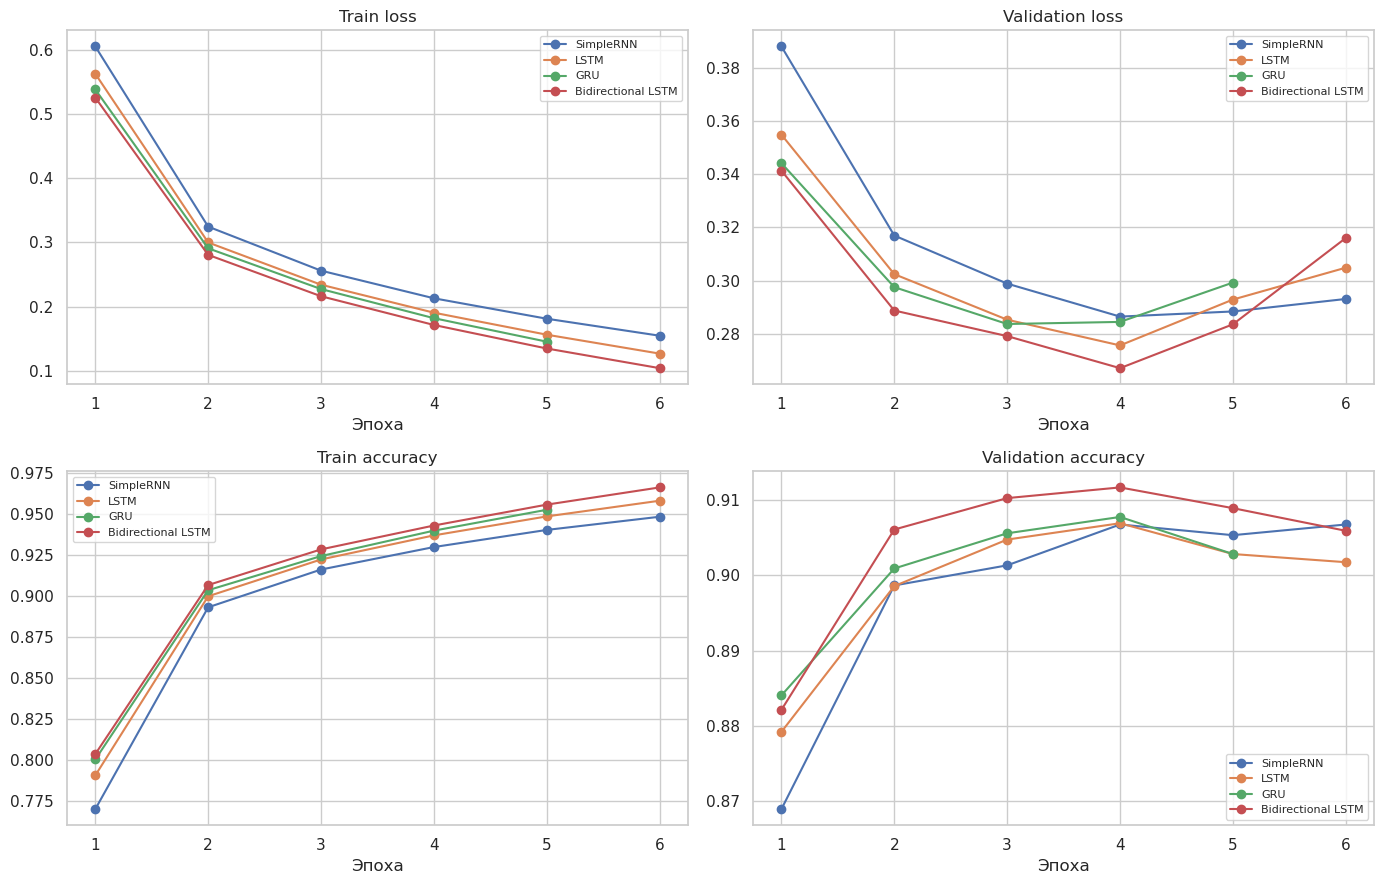

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for name, experiment in experiments.items():
    hist = experiment["history"]
    for ax, metric, split in [(axes[0, 0], "loss", "train"), (axes[0, 1], "loss", "val"),
                             (axes[1, 0], "accuracy", "train"), (axes[1, 1], "accuracy", "val")]:
        ax.plot(hist.epoch, hist[f"{split}_{metric}"], "-o", label=name)
for ax, title in zip(axes.flat, ["Train loss", "Validation loss", "Train accuracy", "Validation accuracy"]):
    ax.set(title=title, xlabel="Эпоха")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(AUDIT_DIR / "all_learning_curves.png", dpi=150)
plt.show()

В начале у всех моделей быстро падает loss и растёт accuracy. Лучший validation loss достигается на 4-й эпохе у SimpleRNN, LSTM и BiLSTM, на 3-й — у GRU. Затем train loss продолжает снижаться, а validation loss растёт: начинается переобучение. Наиболее заметно после лучшей эпохи ухудшается BiLSTM. Усложнение модели не отменяет необходимость ранней остановки.

BiLSTM достигает наименьшего validation loss (0,2670). LSTM — 0,2756, GRU — 0,2836, SimpleRNN — 0,2864. Train измерялся с dropout при меняющихся весах, validation — без dropout при фиксированных; разницу кривых нельзя трактовать как точную оценку разрыва обобщения.

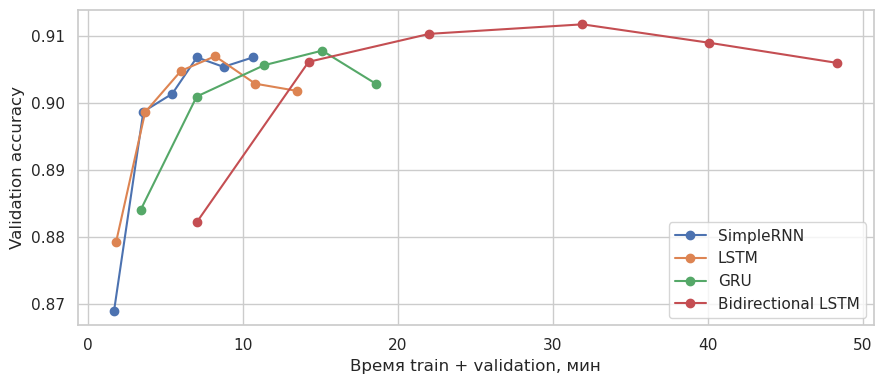

In [102]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, experiment in experiments.items():
    hist = experiment["history"]
    ax.plot(hist.seconds.cumsum() / 60, hist.val_accuracy, "-o", label=name)
ax.set(xlabel="Время train + validation, мин", ylabel="Validation accuracy")
ax.legend()
fig.tight_layout()
fig.savefig(AUDIT_DIR / "accuracy_by_time.png", dpi=150)
plt.show()

По сохранённым замерам SimpleRNN обучается быстрее остальных, BiLSTM — медленнее. Сравнение по эпохам скрывает разную стоимость одного прохода. Время BiLSTM включает обработку упакованных последовательностей и не изолирует влияние самой двунаправленности.

In [103]:
per_class = pd.DataFrame({name: pd.DataFrame(classification_report(
    exp["test"]["truth"], exp["test"]["predicted"], labels=list(range(len(class_to_idx))),
    target_names=label_names, output_dict=True, zero_division=0)).T.loc[label_names, "f1-score"]
    for name, exp in experiments.items()})
per_class.round(4)

,SimpleRNN,LSTM,GRU,Bidirectional LSTM
Мир,0.9040,0.9071,0.9090,0.9094
Спорт,0.9589,0.9489,0.9532,0.9576
Бизнес,0.8685,0.8648,0.8679,0.8740
Наука и технологии,0.8779,0.8825,0.8855,0.8913


In [104]:
selected_model = comparison.best_val_loss.idxmin()
print("Выбрана по validation loss:", selected_model)
print("Лидер по test accuracy:", comparison.test_accuracy.idxmax())

Выбрана по validation loss: Bidirectional LSTM
Лидер по test accuracy: Bidirectional LSTM


# 8. Матрица спутанности и анализ ошибок лучшей модели

In [105]:
selected = experiments[selected_model]["test"]
print(classification_report(selected["truth"], selected["predicted"], labels=list(range(len(class_to_idx))),
                            target_names=label_names, digits=4, zero_division=0))

                    precision    recall  f1-score   support

               Мир     0.9263    0.8932    0.9094      1900
             Спорт     0.9531    0.9621    0.9576      1900
            Бизнес     0.8685    0.8795    0.8740      1900
Наука и технологии     0.8853    0.8974    0.8913      1900

          accuracy                         0.9080      7600
         macro avg     0.9083    0.9080    0.9081      7600
      weighted avg     0.9083    0.9080    0.9081      7600



In [106]:
selected_cm = confusion_matrix(selected["truth"], selected["predicted"], labels=list(range(len(class_to_idx))))

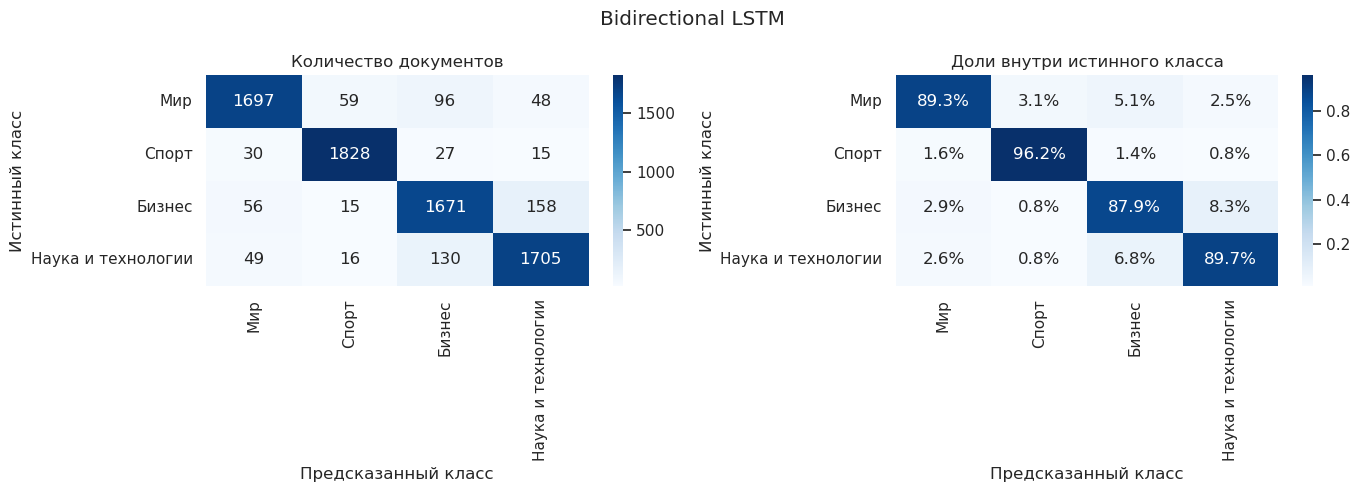

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(selected_cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[0])
sns.heatmap(selected_cm / selected_cm.sum(1, keepdims=True), annot=True, fmt=".1%", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
for ax, title in zip(axes, ["Количество документов", "Доли внутри истинного класса"]):
    ax.set(title=title, xlabel="Предсказанный класс", ylabel="Истинный класс")
fig.suptitle(selected_model)
fig.tight_layout()
fig.savefig(AUDIT_DIR / "best_confusion_matrix.png", dpi=150)
plt.show()

По критерию validation loss выбрана **Bidirectional LSTM**; она же показала лучшую test accuracy. На test допущено **699 ошибок из 7 600**. Лучше всего распознаётся спорт: F1=0,9576, recall=0,9621. Наименьший F1 у бизнеса — 0,8740. Из 699 ошибок **288 (41,2%)** приходятся на взаимную путаницу бизнеса и технологий: 158 «бизнес → технологии» и 130 в обратном направлении.

In [108]:
predictions = pd.DataFrame({"source_row": prepared_splits["test"].source_row,
    "label": selected["truth"], "predicted_label": selected["predicted"]})
errors = predictions.loc[predictions.label.ne(predictions.predicted_label)]
error_pairs = errors.groupby(["label", "predicted_label"]).size().sort_values(ascending=False)
error_pairs.rename("Количество ошибок").to_frame()

Количество ошибок
label predicted_label                   
2     3                              158
3     2                              130
0     2                               96
      1                               59
2     0                               56
3     0                               49
0     3                               48
1     0                               30
      2                               27
3     1                               16
1     3                               15
2     1                               15

In [109]:
examples = []
for (true_label, predicted_label), count in error_pairs.head(5).items():
    row = errors.loc[errors.label.eq(true_label) & errors.predicted_label.eq(predicted_label)].sort_values("source_row").iloc[0]
    index = int(row.source_row)
    text = frames["test"].iloc[index]
    examples.append({"source_row": index, "true_class": label_names[true_label],
        "predicted_class": label_names[predicted_label], "Title": text.Title,
        "Description": text.Description, "pair_error_count": int(count)})
error_examples = pd.DataFrame(examples)

In [110]:
with pd.option_context("display.max_colwidth", None):
    display(error_examples)

,source_row,true_class,predicted_class,Title,Description,pair_error_count
0,83,Бизнес,Наука и технологии,Intel to delay product aimed for high-definition TVs,"SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the launch of a video display chip it had previously planned to introduce by year end, putting off a showdown with Texas Instruments Inc. in the fast-growing market for high-definition television displays.",158
1,9,Наука и технологии,Бизнес,"Card fraud unit nets 36,000 cards","In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - and estimates it saved 65m.",130
2,50,Мир,Бизнес,US fighter squadron to be deployed in South Korea next month (AFP),"AFP - A squadron of US Air Force F-15E fighters based in Alaska will fly to South Korea next month for temporary deployment aimed at enhancing US firepower on the Korean peninsula, US authorities said.",96
3,79,Мир,Спорт,Live: Olympics day four,Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.,59
4,378,Бизнес,Мир,Will High Oil Prices Lead to Recession? (AP),"AP - High oil prices, which have been a factor in virtually all U.S. recessions over the past three decades, are surging again this year. And the higher crude oil prices climb, the more risk energy costs pose to what, until recently, many expected to be a banner year for the U.S. economy.",56


Разбор пяти примеров (source_row — индекс строки исходного test, начиная с нуля):

1. **Строка 83: Intel переносит выпуск чипа для телевизоров. Бизнес → наука и технологии.** В тексте одновременно описаны технология чипа и коммерческие планы компании, конкуренция и рынок. Предсказание тематически правдоподобно, но не совпадает с меткой; пример показывает пересечение категорий, а не однозначно испорченную разметку.
2. **Строка 9: подразделение по борьбе с карточным мошенничеством. Наука и технологии → бизнес.** Упоминания карт, мошенничества и сэкономленных средств создают финансовый контекст. Технологическая составляющая в коротком описании почти не раскрыта. Это возможное объяснение путаницы по содержанию, а не доказательство того, какие слова определили решение сети.
3. **Строка 50: переброска американских истребителей в Южную Корею. Мир → бизнес.** Содержание явно относится к военной и международной тематике; очевидного делового сюжета нет. Здесь предсказание выглядит содержательно ошибочным. По одному примеру нельзя достоверно установить причину: для этого нужен отдельный анализ влияния токенов или устойчивости предсказания к изменениям текста.
4. **Строка 79: четвёртый день Олимпиады. Мир → спорт.** Новость посвящена спортсменам и борьбе за золото. Предсказание «спорт» соответствует явному содержанию, тогда как метка набора — «мир». Это повод проверить правила категоризации или разметку, но не автоматически исправлять метку ради повышения метрики.
5. **Строка 378: высокие цены на нефть и риск рецессии. Бизнес → мир.** Новость затрагивает национальную экономику и широкий общественный контекст, однако основной сюжет — цены на нефть, издержки и рецессия — поддерживает метку «бизнес». Возможна путаница экономических и общенациональных новостей; это интерпретация текста, не установленный механизм решения.

Примеры намеренно взяты из самых частых направлений путаницы и не описывают все ошибки модели. Их просмотр нужен для понимания ограничений; test не используется для изменения словаря, параметров или дообучения. В дальнейшем можно проверять неоднозначную разметку на обучающих данных, изучать ошибки на validation и оценивать устойчивость результатов по нескольким seed.

In [111]:
error_token_info = []
for index in error_examples.source_row:
    sequence = encoded["test"]["sequences"][index]
    error_token_info.append({"source_row": index,
        "original_token_length": int(prepared_splits["test"].iloc[index].token_length),
        "encoded_length": len(sequence), "unknown_tokens": sequence.count(UNK_IDX)})
pd.DataFrame(error_token_info)

,source_row,original_token_length,encoded_length,unknown_tokens
0,83,58,58,0
1,9,32,32,1
2,50,47,47,1
3,79,21,21,1
4,378,62,62,0


Пять примеров содержат 58, 32, 47, 21 и 62 токена, поэтому не обрезались при MAX_LEN=128. В трёх примерах есть по одному UNK; наличие неизвестного токена само по себе не доказывает причину ошибки.

# 9. Итоговое сравнение архитектур

| Архитектура | Что добавляет | Ограничения и область применения |
|---|---|---|
| SimpleRNN | Последовательное скрытое состояние учитывает порядок слов | Труднее обучать далёкие зависимости из-за затухания градиента; простой базовый вариант для коротких текстов |
| LSTM | Отдельная память и вентили помогают сохранять важный контекст | Больше операций и весов; полезна при длинных зависимостях, но не исключает переобучение |
| GRU | Управляемое обновление состояния без отдельной памяти LSTM | Компактнее LSTM при том же hidden size; альтернативный компромисс, а не обязательное улучшение качества или скорости |
| Bidirectional LSTM | Состояния учитывают контекст слева и справа | Полезна, когда весь текст доступен сразу; удваивает рекуррентные направления и не подходит для обработки потока без доступа к будущим словам |

Это не гарантированная лестница качества: GRU является альтернативой LSTM, а двунаправленность — независимым свойством, которое можно добавить и к другим рекуррентным блокам. Более сложная архитектура оправдана, когда выигрыш на validation устойчив в повторных запусках и перевешивает стоимость вычислений и задержку. При близком качестве на коротких новостях более простая модель может быть предпочтительнее.

Наш эксперимент использует один seed и усреднение состояний всех позиций. Сам по себе результат не доказывает, что конкретная модель лучше запоминает далёкие связи. Правое обрезание до MAX_LEN сохраняется для всех моделей; двунаправленность не восстанавливает отброшенный текст.

### Практический вывод по этому эксперименту

BiLSTM получила 90,80% test accuracy против 90,11% у LSTM, 90,42% у GRU и 90,24% у SimpleRNN. Прирост относительно LSTM — 0,70 п.п., относительно GRU — 0,38 п.п. При этом обучение BiLSTM заняло 48,35 минуты против 13,52, 18,58 и 10,67 минуты соответственно в сохранённых CPU-запусках. Это умеренный выигрыш качества при значительно большей стоимости; сравнение времени не является изолированным бенчмарком из-за меняющейся нагрузки и разной обработки padding.

Если приоритет — максимальное качество готовых текстов и доступны ресурсы, BiLSTM является кандидатом для дальнейшей проверки. Если важны простота и стоимость, SimpleRNN даёт близкий результат существенно быстрее в этих запусках. GRU здесь компактнее LSTM по рекуррентным весам, но не быстрее. Для окончательного выбора нужно подтвердить устойчивость различий на validation по нескольким seed, учитывая задержку и память; повторно подбирать параметры на test нельзя.

## Сохранение итоговых результатов

In [112]:
comparison.to_csv(AUDIT_DIR / "comparison.csv")
per_class.to_csv(AUDIT_DIR / "per_class_f1.csv")
error_examples.to_csv(AUDIT_DIR / "error_examples.csv", index=False)
removed_df.drop(columns="tokens").to_csv(AUDIT_DIR / "excluded_train_rows.csv", index=False)
print("Результаты сохранены:", AUDIT_DIR)

Результаты сохранены: /home/jovyan/work/audit_results
